# Lite LLM Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import glob

### Prisma Migrations

In [7]:
files = glob.glob("data/litellm/public._prisma_migrations/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head(3)

## seems like some aux migrations - not important


,id,checksum,finished_at,migration_name,logs,rolled_back_at,started_at,applied_steps_count
0,df17cff0-657b-43ab-a0d1-1b402e9a3034,f5a4569816cb7fb1166c231789f0e5e732fd6c0c34b8f5...,2025-08-30 03:51:34.361161+00,20250326162113_baseline,None,None,2025-08-30 03:51:34.116635+00,1
1,aeaa6779-89f4-4b83-8aa1-3daa1119048f,758f9d3422e8b169973658b607dc2a5f8859a69decd032...,2025-08-30 03:51:34.390362+00,20250326171002_add_daily_user_table,None,None,2025-08-30 03:51:34.362861+00,1
2,83a2fb02-7dfc-4b20-9ac2-dc50ea8105c9,ed0d84d0e48ae306578bf19e351f6a17e49b421d4e1ef2...,2025-09-29 13:14:25.173043+00,20250918083359_drop_spec_version_column_from_m...,None,None,2025-09-29 13:14:25.083291+00,1


### AuditLog

In [9]:
files = glob.glob("data/litellm/public.LiteLLM_AuditLog/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

##empty so not important

,id,updated_at,changed_by,changed_by_api_key,action,table_name,object_id,before_value,updated_values


### Budget Table

In [63]:
files = glob.glob("data/litellm/public.LiteLLM_BudgetTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.describe()


## different budgets - only 3 it seems - we could propose new budgeting strategies

,max_budget,soft_budget,max_parallel_requests,tpm_limit,rpm_limit
count,1.0,0.0,2.0,1.0,3.000000
mean,1.0,NaN,5.0,25000.0,13.333333
std,NaN,NaN,0.0,NaN,14.433757
min,1.0,NaN,5.0,25000.0,5.000000
25%,1.0,NaN,5.0,25000.0,5.000000
50%,1.0,NaN,5.0,25000.0,5.000000
75%,1.0,NaN,5.0,25000.0,17.500000
max,1.0,NaN,5.0,25000.0,30.000000


In [64]:
df

## only 6 budgets and quite uninteresting

,budget_id,max_budget,soft_budget,max_parallel_requests,tpm_limit,rpm_limit,model_max_budget,budget_duration,budget_reset_at,created_at,created_by,updated_at,updated_by
0,Public AI Free Tier,NaN,NaN,NaN,NaN,5.0,None,None,None,2025-08-31 03:11:43.065,default_user_id,2025-08-31 03:11:43.065,default_user_id
1,bc49bba7-3343-4f03-8601-a4c278228c24,NaN,NaN,NaN,NaN,5.0,None,None,None,2025-08-31 03:49:46.845,default_user_id,2025-08-31 04:26:44.141,default_user_id
2,c1cfc6d4-34c4-46ac-802e-8825a8f96869,NaN,NaN,5.0,NaN,NaN,None,None,None,2025-08-31 04:51:09.495,default_user_id,2025-08-31 04:51:09.495,default_user_id
3,23f17d35-a4c7-46e3-a843-c8f12350cb68,NaN,NaN,5.0,NaN,NaN,None,None,None,2025-08-31 04:51:41.239,default_user_id,2025-08-31 04:51:41.239,default_user_id
4,public_ai_free,1.0,NaN,NaN,25000.0,30.0,None,24h,2025-10-01 06:25:55.976,2025-08-31 05:04:18.394,default_user_id,2025-09-06 11:13:49.038,default_user_id
5,8c248429-e911-4170-9103-d3837dbf5186,NaN,NaN,NaN,NaN,NaN,None,None,2025-08-31 04:49:44.582,2025-08-31 04:50:39.215,default_user_id,2025-08-31 04:50:39.215,default_user_id


### Config

In [13]:
files = glob.glob("data/litellm/public.LiteLLM_Config/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

## seems like config settings - not important

,param_name,param_value
0,model_cost_map_reload_config,"{""force_reload"": true, ""interval_hours"": null}"


### CronJob

In [15]:
files = glob.glob("data/litellm/public.LiteLLM_CronJob/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.size

## seems empty - not important


0

### DailtyTagSpend

In [17]:
files = glob.glob("data/litellm/public.LiteLLM_DailyTagSpend/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head(3)

,id,tag,date,api_key,model,model_group,custom_llm_provider,prompt_tokens,completion_tokens,cache_read_input_tokens,cache_creation_input_tokens,spend,api_requests,successful_requests,failed_requests,created_at,updated_at,mcp_namespaced_tool_name
0,cce6c2d8-5f87-4e11-bf5d-c9e0c5518ecb,User-Agent: Python/3.11 aiohttp/3.12.15,2025-08-30,95400db676f8aaabee0a3c934a5a9ed46d90dfc0c910f9...,openai/gpt-oss-120b,gpt-oss-120b,together_ai,19189,4452,0,0,0.005550,21,21,0,2025-08-30 08:08:34.806,2025-08-30 15:00:23.866,
1,28ba880d-1343-4e02-a1c1-fdb83ecf359a,User-Agent: python-requests,2025-08-30,95400db676f8aaabee0a3c934a5a9ed46d90dfc0c910f9...,cohere.embed-multilingual-v3,cohere-embed-multilingual-v3,bedrock,25122,0,0,0,0.002512,152,152,0,2025-08-30 13:54:51.353,2025-08-30 13:55:02.228,
2,57bab41f-d09a-4f32-b7b5-9cbc329e0430,User-Agent: python-requests/2.32.4,2025-08-30,95400db676f8aaabee0a3c934a5a9ed46d90dfc0c910f9...,cohere.embed-multilingual-v3,cohere-embed-multilingual-v3,bedrock,25122,0,0,0,0.002512,152,152,0,2025-08-30 13:54:51.353,2025-08-30 13:55:02.228,


<Axes: title={'center': 'Daily Tag Spend Over Time'}, xlabel='model_group'>

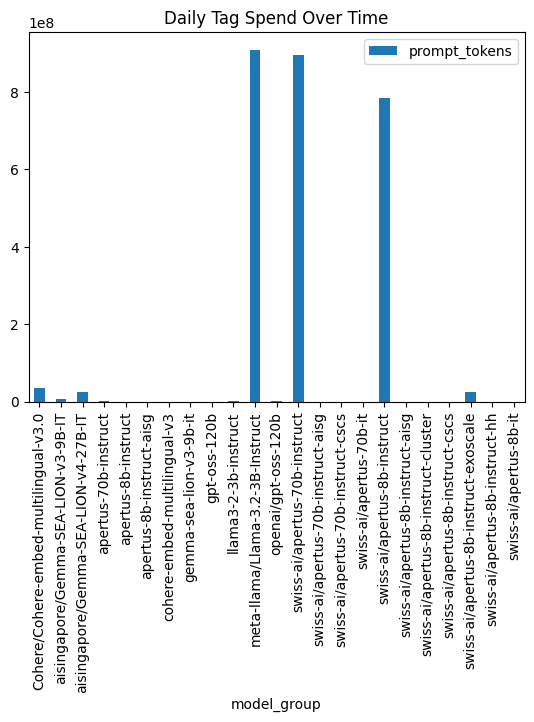

In [22]:
df_grouped = df.groupby('model_group')["prompt_tokens"].sum().reset_index()
df_grouped.plot(x = "model_group", y = "prompt_tokens",kind = "bar" , title = "Daily Tag Spend Over Time")

In [23]:
## So why are there models like llamma and not only aperatus
## so these are spend logs per api call -  not clear how do we use specifically the fact that the table is per tag


### DailyTeamSpend

In [24]:
files = glob.glob("data/litellm/public.LiteLLM_DailyTeamSpend/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head(3)

,id,team_id,date,api_key,model,model_group,custom_llm_provider,prompt_tokens,completion_tokens,spend,api_requests,successful_requests,failed_requests,created_at,updated_at,cache_creation_input_tokens,cache_read_input_tokens,mcp_namespaced_tool_name
0,ca681794-86b9-4e07-9fc8-8d0818dc9483,78524c15-3112-4bee-9fb0-ec5ae9453241,2025-08-31,,gpt-oss-120b,,,0,0,0.0,6,0,6,2025-08-31 03:20:29.119,2025-08-31 20:33:56.371,0,0,
1,5750c5b8-7ea1-48c7-8d69-6d1445f295b0,,2025-08-30,,,,,0,0,0.0,17,0,17,2025-08-30 14:49:30.199,2025-08-30 14:53:21.101,0,0,
2,83e9d7ea-b369-4e00-8d8e-0948fd538e1d,,2025-08-31,,llama3-2-3b-instruct,,,0,0,0.0,7,0,7,2025-08-31 01:56:44.551,2025-08-31 02:11:19.191,0,0,


<Axes: title={'center': 'Daily Team Spend Over Time'}, xlabel='team_id'>

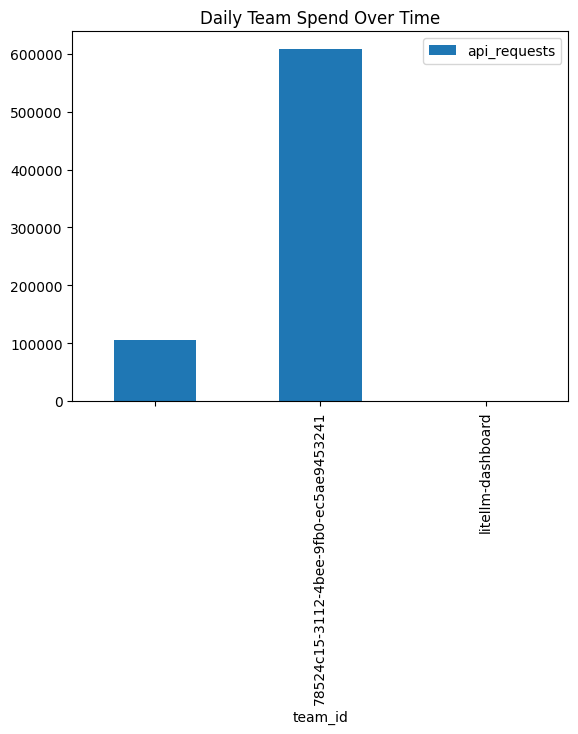

In [25]:
df_grouped = df.groupby("team_id")["api_requests"].sum().reset_index()
df_grouped.plot(x = "team_id", y = "api_requests",kind = "bar" , title = "Daily Team Spend Over Time")

## theres only one team - not much to analyze

### DailyUserSpend

In [26]:
files = glob.glob("data/litellm/public.LiteLLM_DailyUserSpend/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head(3)

,id,user_id,date,api_key,model,model_group,custom_llm_provider,prompt_tokens,completion_tokens,spend,created_at,updated_at,api_requests,failed_requests,successful_requests,cache_creation_input_tokens,cache_read_input_tokens,mcp_namespaced_tool_name
0,7c4303ee-8359-4c12-87d6-4f2090631b70,default_user_id,2025-08-31,,apertus-70b-instruct,apertus-70b-instruct,,0,0,0.000000,2025-08-31 13:53:27.578,2025-08-31 23:38:04.416,7,7,0,0,0,
1,e916b913-22e0-4ec0-9804-cac7bfdce7d0,bc49bba7-3343-4f03-8601-a4c278228c24,2025-08-31,95400db676f8aaabee0a3c934a5a9ed46d90dfc0c910f9...,openai/gpt-oss-120b,gpt-oss-120b,together_ai,4364,1030,0.001273,2025-08-31 01:56:15.957,2025-08-31 02:13:42.178,17,0,17,0,0,
2,8f02dc44-f6f4-4418-ba9f-a05530ecd240,,2025-08-30,,,,,0,0,0.000000,2025-08-30 14:49:30.191,2025-08-30 14:53:21.095,17,17,0,0,0,


In [29]:
df["user_id"].unique()

## again only 4 users, theres nothing to analyze here - on per user basis

array(['default_user_id', 'bc49bba7-3343-4f03-8601-a4c278228c24', '',
       'f7f2534a-011b-4351-891b-199136ac9a41'], dtype=object)

In [31]:
df.describe()

,prompt_tokens,completion_tokens,spend,api_requests,failed_requests,successful_requests,cache_creation_input_tokens,cache_read_input_tokens
count,7.040000e+02,7.040000e+02,704.000000,704.000000,704.000000,704.000000,704.0,704.0
mean,1.908023e+06,4.006268e+05,0.137815,1013.920455,64.863636,949.056818,0.0,0.0
std,6.947092e+06,1.669258e+06,0.856324,3411.886938,444.844213,3400.938075,0.0,0.0
min,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.0,0.0
25%,0.000000e+00,0.000000e+00,0.000000,3.000000,0.000000,0.000000,0.0,0.0
50%,1.155000e+02,0.000000e+00,0.000000,48.500000,0.000000,1.500000,0.0,0.0
75%,5.282792e+05,7.150275e+04,0.000000,501.750000,4.000000,417.500000,0.0,0.0
max,7.587174e+07,2.106193e+07,12.295583,38964.000000,8222.000000,38964.000000,0.0,0.0


<Axes: title={'center': 'Daily User Spend Over Time'}, xlabel='user_id'>

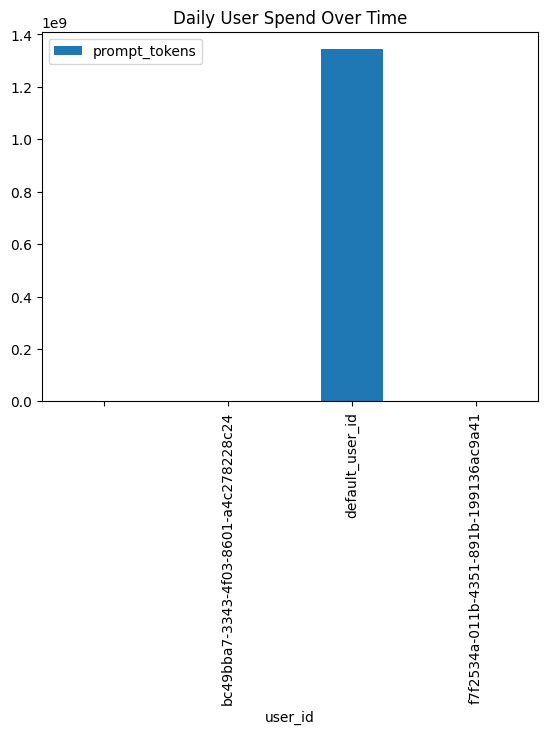

In [27]:
df_grouped = df.groupby("user_id")["prompt_tokens"].sum().reset_index()
df_grouped.plot(x = "user_id", y = "prompt_tokens",kind = "bar" , title = "Daily User Spend Over Time")

### EndUserTable

In [43]:
files = glob.glob("data/litellm/public.LiteLLM_EndUserTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

## So this is quite interesting - theres a lot of end users - 23k and these are their total  spends I would assume, and we see budgets
## I do not understand what is the DailyUserSpend table then since it seems to have only 4 users and they have different conventions of naming

,user_id,alias,spend,allowed_model_region,default_model,budget_id,blocked
0,enduser_23698314,None,0.001115,None,None,public_ai_free,False
1,enduser_9d6a4807,None,0.000820,None,None,Public AI Free Tier,False
2,enduser_54500eeb,None,0.000560,None,None,None,False
3,enduser_3a9a9d4d,None,0.006168,None,None,public_ai_free,False
4,enduser_8f18a31e,None,0.000000,None,None,bc49bba7-3343-4f03-8601-a4c278228c24,False


In [45]:
df["user_id"].nunique()

23805

### GuardrailsTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_GuardrailsTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

## seems empty - not important

0

### HealthCheckTable 

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_HealthCheckTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

## again seems empty - not important

0

### ManagedFileTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_ManagedFileTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

## seems empty - not important

0

### ManagedObjectTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_ManagedObjectTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)
## seems empty - not important

0

### ManagedVectorStoresTable

In [57]:
files = glob.glob("data/litellm/public.LiteLLM_ManagedVectorStoresTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df
## seems empty - not important

,vector_store_id,custom_llm_provider,vector_store_name,vector_store_description,vector_store_metadata,created_at,updated_at,litellm_credential_name,litellm_params


### MCPServerTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_MCPServerTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)
## seems empty - not important

0

### ModelTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_ModelTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

## seems empty - not important

,id,aliases,created_at,created_by,updated_at,updated_by


### ObjectPermissionTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_ObjectPermissionTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

## one entry - not important

1

### OrganizationTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_OrganizationTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

## empty - not important

0

### PromptTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_PromptTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df

## empty - not important ubut prmpts could be important, but we just dont have it

,id,prompt_id,litellm_params,prompt_info,created_at,updated_at


### ProxyModelTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_ProxyModelTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

### seems empty - not important

,model_id,model_name,litellm_params,model_info,created_at,created_by,updated_at,updated_by


### SpendLogs

In [105]:
files = glob.glob("data/litellm/public.LiteLLM_SpendLogs/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

## can be linked to end users which is nice - can define users, idk if the enduser table is any relevant for use- we can just get if from grouping this table


,request_id,call_type,api_key,spend,total_tokens,prompt_tokens,completion_tokens,startTime,endTime,completionStartTime,...,request_tags,team_id,end_user,requester_ip_address,messages,response,proxy_server_request,session_id,status,mcp_namespaced_tool_name
0,chatcmpl-07b28b64-5158-4c65-8897-769b5ddf4cbb,acompletion,None,0.000062,327,291,36,2025-08-30 03:59:21.616,2025-08-30 03:59:23.435,2025-08-30 03:59:23.434,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,d67ab01f-d871-45b3-8a11-44faef043f47,success,None
1,chatcmpl-18887802-83a5-4291-95ca-ddec5d092742,acompletion,None,0.000071,372,361,11,2025-08-30 03:59:23.547,2025-08-30 03:59:23.879,2025-08-30 03:59:23.879,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,fb112d1a-a8a9-4c4c-933a-3ce2df135205,success,None
2,chatcmpl-a6517e27-6f25-48a0-9f2a-309b9cdb33ea,acompletion,None,0.000060,315,246,69,2025-08-30 03:59:24.048,2025-08-30 03:59:25.196,2025-08-30 03:59:25.195,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,4f05525f-da77-4a99-9ada-5e2568caf110,success,None
3,chatcmpl-dbeda3e0-fb15-4372-a599-d4113c18d103,acompletion,None,0.000060,316,281,35,2025-08-30 03:59:32.749,2025-08-30 03:59:33.409,2025-08-30 03:59:33.409,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,be0bc61a-1d0d-4460-a08d-4ad43b793009,success,None
4,chatcmpl-587d7cc6-afb5-456b-aacd-c4ad4744f868,acompletion,None,0.000069,364,351,13,2025-08-30 03:59:33.945,2025-08-30 03:59:34.33,2025-08-30 03:59:34.329,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,35eff4ee-043c-4fa1-b73e-b1537ad1d7f4,success,None


In [106]:
## relevant columns: request_id, spend, total_tokens, prompt_tokens, completion_tokens, startTime, endTime, 

df.iloc[df["spend"].argmax()]



## the llm  provider and api_base can be interesting:

# If your system uses something like LiteLLM or LangChain, it may route requests across:

# openai → GPT-4, GPT-3.5
# bedrock → Claude 3, Llama 3, Mistral
# ollama → local models

## also we can check the time of prompt creation using start time and end time

request_id                      chatcmpl-ee1b2f5f-96a6-471c-b5eb-caf36650463d
call_type                                                         acompletion
api_key                                                                  None
spend                                                                0.013731
total_tokens                                                            72267
prompt_tokens                                                           64075
completion_tokens                                                        8192
startTime                                             2025-09-02 10:00:37.447
endTime                                               2025-09-02 10:03:05.318
completionStartTime                                   2025-09-02 10:03:05.318
model                                       eu.meta.llama3-2-3b-instruct-v1:0
model_id                    b83416aefaf4f57d51ba88c32fd193b9ad190fff6a9e6e...
model_group                                  meta-llama/Llama-3.

In [107]:
df['startTime'] = pd.to_datetime(df['startTime'], errors='coerce')
df['endTime'] = pd.to_datetime(df['endTime'], errors='coerce')

df['time_diff_sec'] = (df['endTime'] - df['startTime']).dt.total_seconds()



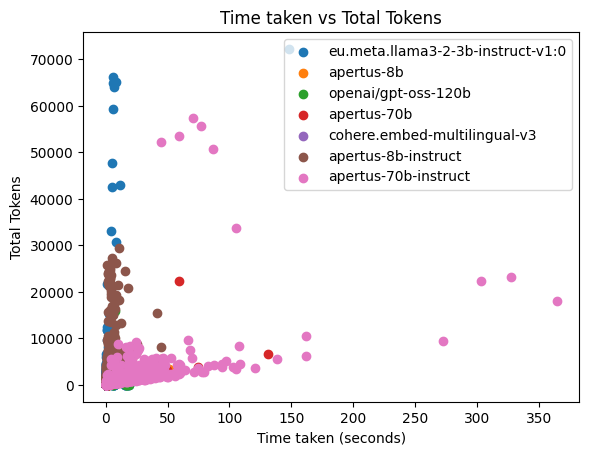

In [108]:
models = df["model"].unique()

for model in models:
    subset_df = df[df["model"] == model]
    subset_df = subset_df[subset_df["time_diff_sec"] < 500]

    if len(subset_df) < 100:
        continue    
    plt.scatter(subset_df["time_diff_sec"], subset_df["total_tokens"], label=model)

plt.xlabel("Time taken (seconds)")
plt.ylabel("Total Tokens")
plt.title("Time taken vs Total Tokens")
plt.legend()
plt.show()

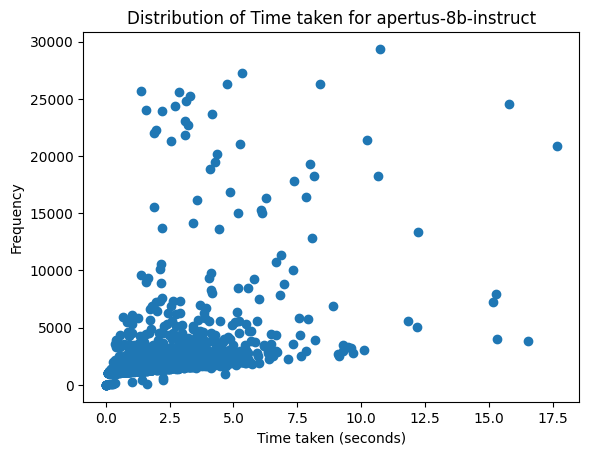

In [117]:
df_aper8b = df[df["model"] == "apertus-8b-instruct"]
df_aper8b = df_aper8b[df_aper8b["time_diff_sec"] < 20]
plt.scatter(df_aper8b["time_diff_sec"], df_aper8b["total_tokens"])
plt.xlabel("Time taken (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Time taken for apertus-8b-instruct")
plt.show()

### TeamMembership

In [120]:
files = glob.glob("data/litellm/public.LiteLLM_TeamMembership/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

## empty - not important


0

### TeamTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_TeamTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df

## only one team - how is this possible 

,team_id,team_alias,organization_id,admins,members,members_with_roles,metadata,max_budget,spend,models,...,budget_duration,budget_reset_at,blocked,created_at,updated_at,model_spend,model_max_budget,model_id,team_member_permissions,object_permission_id
0,78524c15-3112-4bee-9fb0-ec5ae9453241,Open WebUI,None,{},{},"[{""role"": ""admin"", ""user_id"": ""default_user_id...","{""logging"": [], ""guardrails"": []}",NaN,95.183008,{all-proxy-models},...,None,None,False,2025-08-31 03:00:30.757,2025-10-01 03:34:57.976,{},{},NaN,{},None


### UserNotifications

In [123]:
files = glob.glob("data/litellm/public.LiteLLM_UserNotifications/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
len(df)

0

### UserTable

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_UserTable/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df

## so here theres more teams than in the teams table

,user_id,user_alias,team_id,sso_user_id,organization_id,password,teams,user_role,max_budget,spend,...,tpm_limit,rpm_limit,budget_duration,budget_reset_at,allowed_cache_controls,model_spend,model_max_budget,created_at,updated_at,object_permission_id
0,be66e41e-b2d7-45f6-ab43-e79785b034aa,None,78524c15-3112-4bee-9fb0-ec5ae9453241,None,None,None,{78524c15-3112-4bee-9fb0-ec5ae9453241},proxy_admin_viewer,NaN,0.000000,...,NaN,NaN,None,None,{},{},{},2025-09-13 16:24:55.742,2025-09-16 08:35:13.055,None
1,5340d3bd-597e-4601-b63c-57b51769d1ae,None,8aff44bc-3d72-4ae0-8d94-02937ffd516d,None,None,None,{},internal_user,NaN,0.000000,...,NaN,NaN,None,None,{},{},{},2025-08-31 14:40:50.094,2025-09-04 07:30:27.816,None
2,2af338e6-7254-49c5-aa34-a5435a3e5b55,None,78524c15-3112-4bee-9fb0-ec5ae9453241,None,None,None,{78524c15-3112-4bee-9fb0-ec5ae9453241},proxy_admin_viewer,NaN,0.000000,...,NaN,NaN,None,None,{},{},{},2025-09-13 16:22:43.309,2025-09-13 16:22:57.856,None
3,default_user_id,None,None,None,None,None,{78524c15-3112-4bee-9fb0-ec5ae9453241},proxy_admin,NaN,96.989376,...,NaN,NaN,None,None,{},{},{},2025-08-30 04:04:23.382,2025-10-01 03:34:57.957,None


### VerificationToken

In [ ]:
files = glob.glob("data/litellm/public.LiteLLM_VerificationToken/1/*.parquet")  # adjust path
first_file = files[0]                # pick the first file
df = pd.read_parquet(first_file)
df.head()

## not too useful for us

,token,key_name,key_alias,soft_budget_cooldown,spend,expires,models,aliases,config,user_id,...,model_spend,model_max_budget,budget_id,organization_id,created_at,created_by,updated_at,updated_by,allowed_routes,object_permission_id
0,38b5148c3bb2578e3120f4b4f7df62e62d94813e5209b1...,sk-...tT0g,None,False,0.0,2025-08-31 04:04:23.394,{},{},{},default_user_id,...,{},{},None,None,2025-08-30 04:04:23.399,None,2025-08-30 04:04:23.399,None,{},None
1,7b1b496ad6ba2bf6229ec58d189df54efc90d53de0e97f...,sk-...7bSw,None,False,0.0,2025-08-31 07:13:27.355,{},{},{},default_user_id,...,{},{},None,None,2025-08-30 07:13:27.37,None,2025-08-30 07:13:27.37,None,{},None
2,2c68351df3f9ea83e87a39a4f33c046fbc3bc67896cfd5...,sk-...0LxQ,None,False,0.0,2025-09-25 00:00:00,{no-default-models},{},{},be66e41e-b2d7-45f6-ab43-e79785b034aa,...,{},{},None,None,2025-09-24 06:20:21.785,None,2025-09-24 06:20:21.785,None,{},None
3,15732a8151dfe014107d5e446a6848f39809432099c21d...,sk-...IYfg,None,False,0.0,2025-09-27 00:00:00,{no-default-models},{},{},be66e41e-b2d7-45f6-ab43-e79785b034aa,...,{},{},None,None,2025-09-26 14:09:24.381,None,2025-09-26 14:09:24.381,None,{},None
4,110df83905b2ae9e1b0119306ec3442578316c870ab15a...,sk-...Ypxg,None,False,0.0,2025-09-01 02:54:59.315,{},{},{},default_user_id,...,{},{},None,None,2025-08-31 02:54:59.322,None,2025-08-31 02:57:22.503,None,{},None
